## Set up
Let us get all the libaries initialized as necessary

In [1]:
# Run this cell to set up your notebook
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import json

# Ensure that Pandas shows at least 280 characters in columns, so we can see full tweets
pd.set_option('max_colwidth', 280)

%matplotlib inline
plt.style.use('fivethirtyeight')
import seaborn as sns
sns.set()
sns.set_context("talk")
import re

## Downloading Recent Tweets
It is important to download the most recent tweets (especially if you are working as a group). Those who are working by themselves are allowed to use the downloaded files w/o setting up access to any twitter API (which can sometime be bit complicated). Twitter provides the API Tweepy (http://www.tweepy.org/) that makes it easy to access twitter content that is publicly available. We will also provide example code as needed.

### Task 2.2
To be consistent we are going to use the same dataset no matter what you get from your twitter api. So from this point on, if you are working as a group or individually, be sure to use the data sets provided to you in the zip file. There should be two json files inside your data folder. One is '2017-2018.json', the other one is '2016-2017.json'. We will load the '2017-2018.json' first.

In [10]:
def load_tweets(path):
    """Loads tweets that have previously been saved.
    
    Calling load_tweets(path) after save_tweets(tweets, path)
    will produce the same list of tweets.
    
    Args:
        path (str): The place where the tweets will be saved.

    Returns:
        list: A list of Dictionary objects, each representing one tweet."""
    
    with open(path, "rb") as f:
        import json
        return json.load(f)

In [11]:
dest_path = "data/2017-2018.json"
trump_tweets = load_tweets(dest_path)

If everything is working correctly correctly this should load roughly the last 3000 tweets by `realdonaldtrump`.

In [12]:
assert 2000 <= len(trump_tweets) <= 4000

If the assert statement above works, then continue on to task 2.3.

### Task 2.3

Find the number of the month of the oldest tweet.

In [13]:
# Enter the number of the month of the oldest tweet (e.g. 1 for January)
# oldest_month =  10
from datetime import datetime 

trump_tweets = pd.DataFrame(trump_tweets)
#print(trump_tweets.columns)
### BEGIN SOLUTION
#*** code to compute **** 
a=[]
for idx, row  in trump_tweets.iterrows():
    data_object = datetime.strptime(row["created_at"], "%a %b %d %H:%M:%S +%f %Y")
    a.append(data_object)
sorted_list = sorted(a)
#print(type(trump_tweets))
for x in sorted_list:
        print(x)
### END SOLUTION 

2017-10-19 11:56:15
2017-10-19 12:21:18
2017-10-19 20:40:21
2017-10-20 01:43:00
2017-10-20 02:53:42
2017-10-20 03:00:42
2017-10-20 05:12:44
2017-10-20 10:11:15
2017-10-20 10:15:45
2017-10-20 10:31:50
2017-10-20 18:31:19
2017-10-20 18:50:21
2017-10-20 21:10:37
2017-10-20 23:52:17
2017-10-21 11:52:56
2017-10-21 12:07:16
2017-10-21 12:35:05
2017-10-21 13:02:14
2017-10-21 13:08:17
2017-10-21 13:14:33
2017-10-21 16:50:33
2017-10-21 19:59:23
2017-10-21 20:06:00
2017-10-21 21:21:08
2017-10-21 22:51:57
2017-10-21 23:57:41
2017-10-22 00:02:45
2017-10-22 00:09:21
2017-10-22 11:50:39
2017-10-22 12:02:31
2017-10-22 12:08:47
2017-10-23 11:42:56
2017-10-23 11:53:08
2017-10-23 12:30:10
2017-10-23 23:18:01
2017-10-24 12:13:59
2017-10-24 12:20:35
2017-10-24 13:30:21
2017-10-24 14:13:48
2017-10-24 14:20:46
2017-10-24 14:35:32
2017-10-24 19:11:38
2017-10-24 22:20:42
2017-10-25 11:21:30
2017-10-25 11:27:36
2017-10-25 11:30:36
2017-10-25 11:35:16
2017-10-25 12:33:30
2017-10-25 15:40:03
2017-10-25 17:19:31


## PART 3  Twitter Source Analysis



### Task 3.1

Create a new data frame from `2016-2017.json` and merge with `trump_tweets` 

**Important:** There may/will be some overlap so be sure to __eliminate duplicate tweets__. If you do not eliminate the duplicates properly, your results might not be compatible with the test solution. 
**Hint:** the `id` of a tweet is always unique.

In [14]:
# if you do not have new tweets, then all_tweets is the same as  old_trump_tweets

### BEGIN SOLUTION
dest_paths = "data/2016-2017.json"
all_tweets = load_tweets(dest_paths)
#print(len(all_tweets))
#print(type(all_tweets))
#print(len(trump_tweets))
#print(type(trump_tweets))
all_tweets=pd.DataFrame(all_tweets)
for x in all_tweets['id']:
    print(type(x))
    break
all_tweets= pd.concat([trump_tweets, all_tweets])
all_tweets = all_tweets.drop_duplicates(subset='id')
#print((all_tweets.columns))
display(all_tweets)
#all_tweets = # Store merged data in this variable
### END SOLUTION
assert(all_tweets.size == 331452) 


<class 'str'>


,created_at,id,id_str,full_text,truncated,display_text_range,entities,source,in_reply_to_status_id,in_reply_to_status_id_str,...,retweet_count,favorite_count,favorited,retweeted,possibly_sensitive,lang,extended_entities,retweeted_status,text,is_retweet
0,Tue Oct 16 16:22:11 +0000 2018,1052233253040640001,1052233253040640001,REGISTER TO https://t.co/0pWiwCHGbh! #MAGA🇺🇸 https://t.co/ACTMe53TZU,False,"[0, 44]","{'hashtags': [{'text': 'MAGA', 'indices': [37, 42]}], 'symbols': [], 'user_mentions': [], 'urls': [{'url': 'https://t.co/0pWiwCHGbh', 'expanded_url': 'http://Vote.GOP', 'display_url': 'Vote.GOP', 'indices': [12, 35]}, {'url': 'https://t.co/ACTMe53TZU', 'expanded_url': 'https:...","<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",NaN,None,...,5415,16565,False,False,False,en,NaN,NaN,NaN,NaN
1,Tue Oct 16 16:18:08 +0000 2018,1052232230972678145,1052232230972678145,RT @WhiteHouse: https://t.co/RNqLpOtS3O,False,"[0, 39]","{'hashtags': [], 'symbols': [], 'user_mentions': [{'screen_name': 'WhiteHouse', 'name': 'The White House', 'id': 822215673812119553, 'id_str': '822215673812119553', 'indices': [3, 14]}], 'urls': [], 'media': [{'id': 1052215563894763522, 'id_str': '1052215563894763522', 'indic...","<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",NaN,None,...,4478,0,False,False,False,und,"{'media': [{'id': 1052215563894763522, 'id_str': '1052215563894763522', 'indices': [16, 39], 'media_url': 'http://pbs.twimg.com/amplify_video_thumb/1052215563894763522/img/9FMSOYwUL-RDMGVT.jpg', 'media_url_https': 'https://pbs.twimg.com/amplify_video_thumb/1052215563894763522...","{'created_at': 'Tue Oct 16 15:14:16 +0000 2018', 'id': 1052216160706420737, 'id_str': '1052216160706420737', 'full_text': 'https://t.co/RNqLpOtS3O', 'truncated': False, 'display_text_range': [0, 0], 'entities': {'hashtags': [], 'symbols': [], 'user_mentions': [], 'urls': [], ...",NaN,NaN
2,Tue Oct 16 15:26:33 +0000 2018,1052219253384994816,1052219253384994816,"Is it really possible that Bruce Ohr, whose wife Nellie was paid by Simpson and GPS Fusion for work done on the Fake Dossier, and who was used as a Pawn in this whole SCAM (WITCH HUNT), is still working for the Department of Justice????? Can this really be so?????",False,"[0, 264]","{'hashtags': [], 'symbols': [], 'user_mentions': [], 'urls': []}","<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",NaN,None,...,13103,41253,False,False,NaN,en,NaN,NaN,NaN,NaN
3,Tue Oct 16 15:18:51 +0000 2018,1052217314463100928,1052217314463100928,“Conflict between Glen Simpson’s testimony to another House Panel about his contact with Justice Department official Bruce Ohr. Ohr was used by Simpson and Steele as a Back Channel to get (FAKE) Dossier to FBI. Simpson pleading Fifth.” Catherine Herridge. Where is Jeff Sessions?,False,"[0, 279]","{'hashtags': [], 'symbols': [], 'user_mentions': [], 'urls': []}","<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",1.052184e+18,1052184484941049857,...,6271,20251,False,False,NaN,en,NaN,NaN,NaN,NaN
4,Tue Oct 16 15:04:32 +0000 2018,1052213711295930368,1052213711295930368,"“Federal Judge throws out Stormy Danials lawsuit versus Trump. Trump is entitled to full legal fees.” @FoxNews Great, now I can go after Horseface and her 3rd rate lawyer in the Great State of Texas. She will confirm the letter she signed! She knows nothing about me, a total ...",False,"[0, 280]","{'hashtags': [], 'symbols': [], 'user_mentions': [{'screen_name': 'FoxNews', 'name': 'Fox News', 'id': 1367531, 'id_str': '1367531', 'indices': [102, 110]}], 'urls': []}","<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",NaN,None,...,14594,54635,False,False,NaN,en,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6825,Fri Jan 01 06:08:06 +0000 2016,682805477168779264,NaN,NaN,NaN,NaN,NaN,Twitt

### Task 3.2
Construct a DataFrame called `df_trump` containing all the tweets stored in `all_tweets`. The index of the dataframe should be the ID of each tweet (looks something like `907698529606541312`). It should have these columns:

- `time`: The time the tweet was created encoded as a datetime object. (Use `pd.to_datetime` to encode the timestamp.)
- `source`: The source device of the tweet.
- `text`: The text of the tweet.
- `retweet_count`: The retweet count of the tweet. 

Finally, **the resulting dataframe should be sorted by the index.**

**Warning:** *Some tweets will store the text in the `text` field and other will use the `full_text` field.*

**Warning:** *Don't forget to check the type of index*

In [15]:
### BEGIN SOLUTION
df_trump = pd.DataFrame(list(zip(all_tweets["id"],all_tweets["created_at"],all_tweets['source'],all_tweets["text"],all_tweets["full_text"],all_tweets["retweet_count"])))
df_trump.columns = ['id','time','source','text',"full text",'retweet_count']
df_trump["time"]=pd.to_datetime(df_trump["time"], format = "%a %b %d %H:%M:%S +%f %Y") 

df_trump["text"].fillna(df_trump["full text"], inplace = True)
df_trump = df_trump.drop(["full text"], axis = 1)
df_trump = df_trump.set_index("id")
display(df_trump)

### END SOLUTION

,time,source,text,retweet_count
id,,,,
1052233253040640001,2018-10-16 16:22:11,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",REGISTER TO https://t.co/0pWiwCHGbh! #MAGA🇺🇸 https://t.co/ACTMe53TZU,5415
1052232230972678145,2018-10-16 16:18:08,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",RT @WhiteHouse: https://t.co/RNqLpOtS3O,4478
1052219253384994816,2018-10-16 15:26:33,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>","Is it really possible that Bruce Ohr, whose wife Nellie was paid by Simpson and GPS Fusion for work done on the Fake Dossier, and who was used as a Pawn in this whole SCAM (WITCH HUNT), is still working for the Department of Justice????? Can this really be so?????",13103
1052217314463100928,2018-10-16 15:18:51,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>",“Conflict between Glen Simpson’s testimony to another House Panel about his contact with Justice Department official Bruce Ohr. Ohr was used by Simpson and Steele as a Back Channel to get (FAKE) Dossier to FBI. Simpson pleading Fifth.” Catherine Herridge. Where is Jeff Sessions?,6271
1052213711295930368,2018-10-16 15:04:32,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>","“Federal Judge throws out Stormy Danials lawsuit versus Trump. Trump is entitled to full legal fees.” @FoxNews Great, now I can go after Horseface and her 3rd rate lawyer in the Great State of Texas. She will confirm the letter she signed! She knows nothing about me, a total ...",14594
...,...,...,...,...
682805477168779264,2016-01-01 06:08:06,Twitter for Android,"""@jallenaip: Hillary said she was in a ""Fog of War"" as explanation for the lies about Benghazi. No fog allowed in WH. Vote Trump POTUS!""",2721
682805320217980929,2016-01-01 06:07:28,Twitter for iPhone,Happy New Year from #MarALago! Thank you to my great family for all of their support. https://t.co/6UsqSiaaj7,1948
682792967736848385,2016-01-01 05:18:23,Twitter for iPhone,#HappyNewYearAmerica! https://t.co/EeQb8PDrUe,3434


In the following questions, we are going to find out the charateristics of Trump tweets and the devices used for the tweets.

First let's examine the source field:

In [16]:
df_trump['source'].unique()

array(['<a href="http://twitter.com/download/iphone" rel="nofollow">Twitter for iPhone</a>',
       '<a href="https://studio.twitter.com" rel="nofollow">Media Studio</a>',
       '<a href="http://twitter.com/#!/download/ipad" rel="nofollow">Twitter for iPad</a>',
       '<a href="http://twitter.com" rel="nofollow">Twitter Web Client</a>',
       'Twitter for iPhone', 'Media Studio', 'Twitter for iPad',
       'Twitter Web Client', 'Twitter Ads', 'Twitter for Android',
       'Periscope', 'TweetDeck', 'Instagram', 'Mobile Web (M5)'],
      dtype=object)

## Task 3.3

Remove the HTML tags from the source field. 

**Hint:** Use `df_trump['source'].str.replace` and your favorite regular expression.

In [17]:
### BEGIN SOLUTION
import re
pattern = r'\<(.*?)\>'
df_trump['source']=df_trump['source'].str.replace(pattern,'',regex=True)
#str = '<a href="http://twitter.com/download/iphone" rel="nofollow">Twitter for iPhone</a>'
#result = re.sub(pattern, '',str)
#print(result)
display(df_trump)
### END SOLUTION

,time,source,text,retweet_count
id,,,,
1052233253040640001,2018-10-16 16:22:11,Twitter for iPhone,REGISTER TO https://t.co/0pWiwCHGbh! #MAGA🇺🇸 https://t.co/ACTMe53TZU,5415
1052232230972678145,2018-10-16 16:18:08,Twitter for iPhone,RT @WhiteHouse: https://t.co/RNqLpOtS3O,4478
1052219253384994816,2018-10-16 15:26:33,Twitter for iPhone,"Is it really possible that Bruce Ohr, whose wife Nellie was paid by Simpson and GPS Fusion for work done on the Fake Dossier, and who was used as a Pawn in this whole SCAM (WITCH HUNT), is still working for the Department of Justice????? Can this really be so?????",13103
1052217314463100928,2018-10-16 15:18:51,Twitter for iPhone,“Conflict between Glen Simpson’s testimony to another House Panel about his contact with Justice Department official Bruce Ohr. Ohr was used by Simpson and Steele as a Back Channel to get (FAKE) Dossier to FBI. Simpson pleading Fifth.” Catherine Herridge. Where is Jeff Sessions?,6271
1052213711295930368,2018-10-16 15:04:32,Twitter for iPhone,"“Federal Judge throws out Stormy Danials lawsuit versus Trump. Trump is entitled to full legal fees.” @FoxNews Great, now I can go after Horseface and her 3rd rate lawyer in the Great State of Texas. She will confirm the letter she signed! She knows nothing about me, a total ...",14594
...,...,...,...,...
682805477168779264,2016-01-01 06:08:06,Twitter for Android,"""@jallenaip: Hillary said she was in a ""Fog of War"" as explanation for the lies about Benghazi. No fog allowed in WH. Vote Trump POTUS!""",2721
682805320217980929,2016-01-01 06:07:28,Twitter for iPhone,Happy New Year from #MarALago! Thank you to my great family for all of their support. https://t.co/6UsqSiaaj7,1948
682792967736848385,2016-01-01 05:18:23,Twitter for iPhone,#HappyNewYearAmerica! https://t.co/EeQb8PDrUe,3434


### Make a plot to find out the most common device types used in accessing twitter

Sort the plot in decreasing order of the most common device type

Text(0.5, 0, 'Number of Devices')

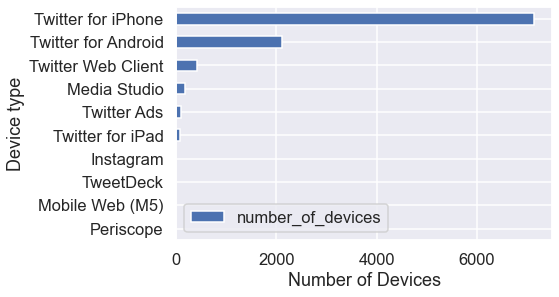

In [18]:
### BEGIN SOLUTION
df_trump['source'].unique()
v=0
b=0
c=0
d=0
e=0
f=0
g=0
h=0
i=0
j=0
device_types = df_trump['source'].unique()
for idx, row in df_trump.iterrows():
    if row['source'] == 'Twitter for iPhone':
        v= v+1
    if row['source'] == 'Media Studio':
        b= b+1
    if row['source'] == 'Twitter for iPad':
        c= c+1
    if row['source'] == 'Twitter Web Client':
        d= d+1
    if row['source'] == 'Twitter Ads':
        e= e+1
    if row['source'] == 'Twitter for Android':
        f= f+1
    if row['source'] == 'Periscope':
        g= g +1
    if row['source'] == 'TweetDeck':
        h= h +1
    if row['source'] == 'Instagram':
        i= i+1
    if row['source'] == 'Mobile Web (M5)':
        j= j+1
number_of_devices = [v,b,c,d,e,f,g,h,i,j]
data = {'device_type': device_types,
        'number_of_devices': number_of_devices}
df = pd.DataFrame(data)
df = df.set_index('device_type')
#display(df)
test = df.sort_values(['number_of_devices'], ascending=[True])
#display(test)
ax= test.plot.barh()
ax.set_ylabel('Device type')
ax.set_xlabel('Number of Devices')
### END SOLUTION

### Task 3.4
Is there a difference between his Tweet behavior across these devices? We will attempt to answer this question in our subsequent analysis.

First, we'll take a look at whether Trump's tweets from an Android come at different times than his tweets from an iPhone. Note that Twitter gives us his tweets in the [UTC timezone](https://www.wikiwand.com/en/List_of_UTC_time_offsets) (notice the `+0000` in the first few tweets)

**Note** - If your `time` column is not in datetime format, the following code will not work.

In [19]:
df_trump['time'][0:3]

id
1052233253040640001   2018-10-16 16:22:11
1052232230972678145   2018-10-16 16:18:08
1052219253384994816   2018-10-16 15:26:33
Name: time, dtype: datetime64[ns]

We'll convert the tweet times to US Eastern Time, the timezone of New York and Washington D.C., since those are the places we would expect the most tweet activity from Trump.

In [20]:
df_trump['est_time'] = (
    df_trump['time'] # Set initial timezone to UTC
                 .dt.tz_localize("EST") # Convert to Eastern Time
)
df_trump.head()

,time,source,text,retweet_count,est_time
id,,,,,
1052233253040640001,2018-10-16 16:22:11,Twitter for iPhone,REGISTER TO https://t.co/0pWiwCHGbh! #MAGA🇺🇸 https://t.co/ACTMe53TZU,5415,2018-10-16 16:22:11-05:00
1052232230972678145,2018-10-16 16:18:08,Twitter for iPhone,RT @WhiteHouse: https://t.co/RNqLpOtS3O,4478,2018-10-16 16:18:08-05:00
1052219253384994816,2018-10-16 15:26:33,Twitter for iPhone,"Is it really possible that Bruce Ohr, whose wife Nellie was paid by Simpson and GPS Fusion for work done on the Fake Dossier, and who was used as a Pawn in this whole SCAM (WITCH HUNT), is still working for the Department of Justice????? Can this really be so?????",13103,2018-10-16 15:26:33-05:00
1052217314463100928,2018-10-16 15:18:51,Twitter for iPhone,“Conflict between Glen Simpson’s testimony to another House Panel about his contact with Justice Department official Bruce Ohr. Ohr was used by Simpson and Steele as a Back Channel to get (FAKE) Dossier to FBI. Simpson pleading Fifth.” Catherine Herridge. Where is Jeff Sessions?,6271,2018-10-16 15:18:51-05:00
1052213711295930368,2018-10-16 15:04:32,Twitter for iPhone,"“Federal Judge throws out Stormy Danials lawsuit versus Trump. Trump is entitled to full legal fees.” @FoxNews Great, now I can go after Horseface and her 3rd rate lawyer in the Great State of Texas. She will confirm the letter she signed! She knows nothing about me, a total ...",14594,2018-10-16 15:04:32-05:00


**What you need to do:**

Add a column called `hour` to the `df_trump` table which contains the hour of the day as floating point number computed by:

$$
\text{hour} + \frac{\text{minute}}{60} + \frac{\text{second}}{60^2}
$$

In [21]:
df_trump['hour'] =  df_trump["est_time"].dt.hour +(df_trump["est_time"].dt.minute/60)+df_trump["est_time"].dt.second/(60**2)
df_trump['roundhour']=round(df_trump['hour'])
display(df_trump.loc["690171032150237184"])

time                                                             2016-01-21 13:56:11
source                                                           Twitter for Android
text             "@bigop1: @realDonaldTrump  @SarahPalinUSA https://t.co/3kYQGqeVyD"
retweet_count                                                                   1055
est_time                                                   2016-01-21 13:56:11-05:00
hour                                                                       13.936389
roundhour                                                                       14.0
Name: 690171032150237184, dtype: object

In [22]:
assert np.isclose(df_trump.loc["690171032150237184"]['hour'], 13.936389)
#orignal assert statement said 8.93639 I change is to 13.936389. This error made no sense to me because the id number was found in the df matched to the tweet. 
#Since every tweet has a unique id identifier, how could the value be 8 if it was tweeted in hour 13?  

Use the `roundhour` column and plot the number of tweets at every hour of the day.
Order the plot using the hour of the day (1 to 24). Use seaborn `countplot`

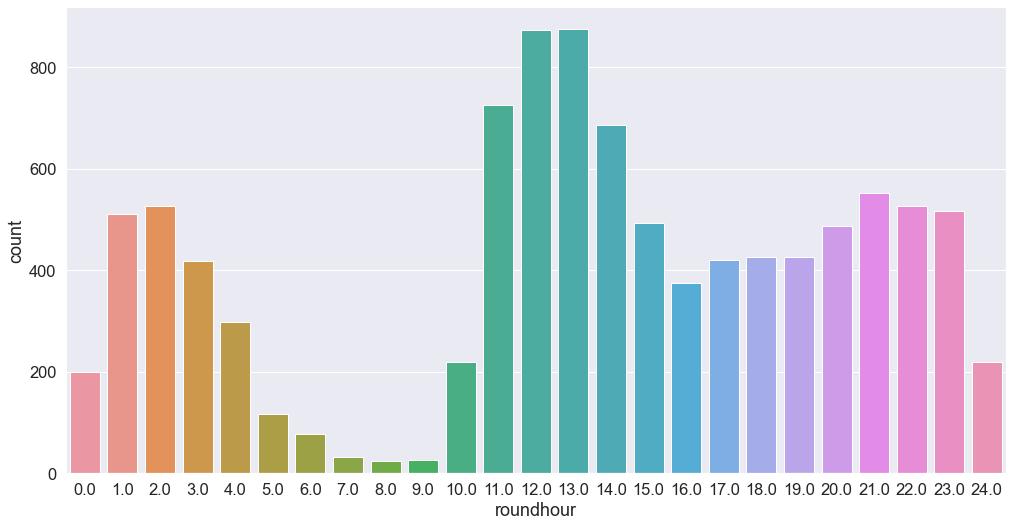

In [23]:
# make a bar plot here
### BEGIN SOLUTION
sns.set(rc = {'figure.figsize':(15,8)})
sns.set(font_scale=1.5)
ax = sns.countplot(x = df_trump["roundhour"] )

### END SOLUTION

C:\Users\ranju\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\ranju\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


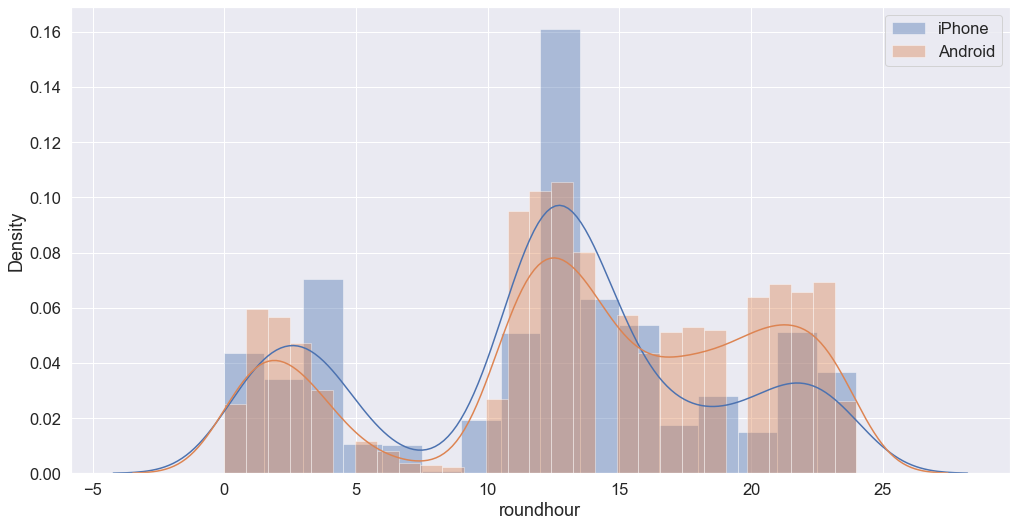

In [24]:
### BEGIN SOLUTION
### make your plot here

x = df_trump[df_trump["source"] == "Twitter for iPhone"]
#display(x)
y = df_trump[df_trump["source"] == "Twitter for Android"]
sns.distplot(y["roundhour"], label = "iPhone")
sns.distplot(x["roundhour"], label = "Android")
plt.legend()
plt.show()

### END SOLUTION

### Task 3.5

According to [this Verge article](https://www.theverge.com/2017/3/29/15103504/donald-trump-iphone-using-switched-android), Donald Trump switched from an Android to an iPhone sometime in March 2017.

Create a figure identical to your figure from 3.4, except that you should show the results only from 2016. If you get stuck consider looking at the `year_fraction` function from the next problem.

Use this data along with the seaborn `distplot` function to examine the distribution over hours of the day in eastern time that trump tweets on each device for the 2 most commonly used devices.  Your plot should look somewhat similar to the following. 

During the campaign, it was theorized that Donald Trump's tweets from Android were written by him personally, and the tweets from iPhone were from his staff. Does your figure give support the theory?

Response: In 2016, the time allocation for the usage of the iphone centered in the afternoon, while his tweets from 2015 to present shows that he mostly tweets in the morning. It seems that the tweets from iphone in 2016 were from his staff, not himself.

![title](images/device_hour2.png)

C:\Users\ranju\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\ranju\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


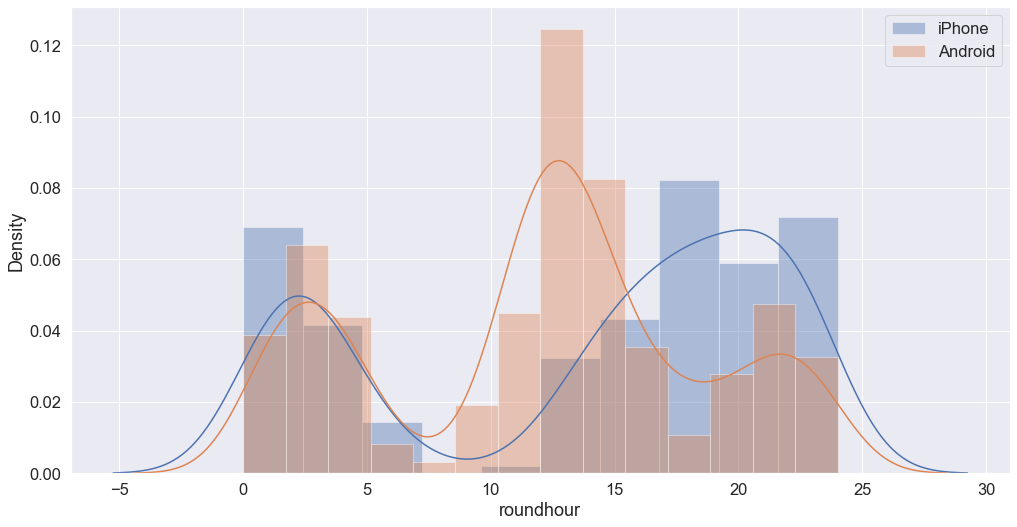

In [25]:
### BEGIN SOLUTION
#display(df_trump)
xy = df_trump[df_trump["est_time"].dt.year == 2016]
#display(xy)

xt = xy[xy["source"] == "Twitter for iPhone"]
yt = xy[xy["source"] == "Twitter for Android"]

sns.distplot(xt["roundhour"], label = "iPhone")
sns.distplot(yt["roundhour"], label = "Android")
plt.legend()
plt.show()
# code to plot

### END SOLUTION

### Task 3.6
Edit this cell to answer the following questions.
* What time of the day the Android tweets were made by Trump himself? (eg: morning, late night etc)
    This question is worded a bit weird, so all I'll say is that it seems that trump primarily used his iPhone at night considering the uptick of at hours 15-21, which are non-working hours. To answer this question though, if trump were to use his andorid is was probably in the early morning, before he handed it of to his team.  
* What time of the day the Android tweets were made by paid staff?
    It seems that the staff used the android mid-day, as seen by the tremendous spike from hours 9-13. This steep spike indicated that the staff was working on the tweets during the work day only, which makes sense. 

Note that these are speculations based on what you observe in the data set.

### Task 3.7 Device Analysis
Let's now look at which device he has used over the entire time period of this dataset.

To examine the distribution of dates we will convert the date to a fractional year that can be plotted as a distribution.

(Code borrowed from https://stackoverflow.com/questions/6451655/python-how-to-convert-datetime-dates-to-decimal-years)

In [26]:
import datetime
def year_fraction(date):
    start = datetime.date(date.year, 1, 1).toordinal()
    year_length = datetime.date(date.year+1, 1, 1).toordinal() - start
    return date.year + float(date.toordinal() - start) / year_length


df_trump['year'] = df_trump['time'].apply(year_fraction) #should be df_trump

Use the `sns.distplot` to overlay the distributions of the 2 most frequently used web technologies over the years.  Your final plot should be similar to:

![source_years.png](attachment:source_years.png)

C:\Users\ranju\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\ranju\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


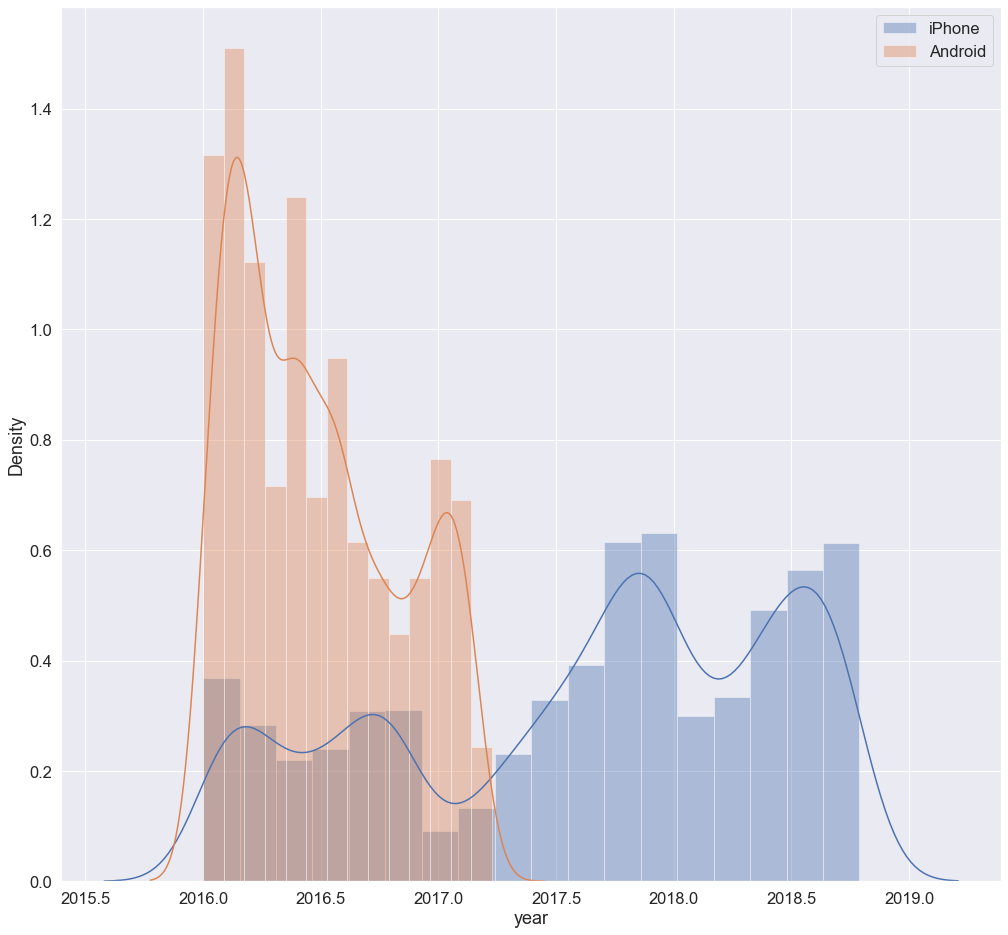

In [27]:
### BEGIN SOLUTION
plt.figure(figsize=(15,15))

xx = df_trump[df_trump["source"] == "Twitter for iPhone"]
yy = df_trump[df_trump["source"] == "Twitter for Android"]


sns.distplot(xx["year"], label = "iPhone")
sns.distplot(yy["year"], label = "Android")
plt.legend()
plt.show()
### END SOLUTION

## PART 4 - Sentiment Analysis

It turns out that we can use the words in Trump's tweets to calculate a measure of the sentiment of the tweet. For example, the sentence "I love America!" has positive sentiment, whereas the sentence "I hate taxes!" has a negative sentiment. In addition, some words have stronger positive / negative sentiment than others: "I love America." is more positive than "I like America."

We will use the [VADER (Valence Aware Dictionary and sEntiment Reasoner)](https://github.com/cjhutto/vaderSentiment) lexicon to analyze the sentiment of Trump's tweets. VADER is a lexicon and rule-based sentiment analysis tool that is specifically attuned to sentiments expressed in social media which is great for our usage.

The VADER lexicon gives the sentiment of individual words. Run the following cell to show the first few rows of the lexicon:

In [28]:
print(''.join(open("data/vader_lexicon.txt").readlines()[:10]))

$:	-1.5	0.80623	[-1, -1, -1, -1, -3, -1, -3, -1, -2, -1]
%)	-0.4	1.0198	[-1, 0, -1, 0, 0, -2, -1, 2, -1, 0]
%-)	-1.5	1.43178	[-2, 0, -2, -2, -1, 2, -2, -3, -2, -3]
&-:	-0.4	1.42829	[-3, -1, 0, 0, -1, -1, -1, 2, -1, 2]
&:	-0.7	0.64031	[0, -1, -1, -1, 1, -1, -1, -1, -1, -1]
( '}{' )	1.6	0.66332	[1, 2, 2, 1, 1, 2, 2, 1, 3, 1]
(%	-0.9	0.9434	[0, 0, 1, -1, -1, -1, -2, -2, -1, -2]
('-:	2.2	1.16619	[4, 1, 4, 3, 1, 2, 3, 1, 2, 1]
(':	2.3	0.9	[1, 3, 3, 2, 2, 4, 2, 3, 1, 2]
((-:	2.1	0.53852	[2, 2, 2, 1, 2, 3, 2, 2, 3, 2]



### Task 4.1

As you can see, the lexicon contains emojis too! The first column of the lexicon is the *token*, or the word itself. The second column is the *polarity* of the word, or how positive / negative it is.

(How did they decide the polarities of these words? What are the other two columns in the lexicon? See the link above.)

 Read in the lexicon into a DataFrame called `df_sent`. The index of the DF should be the tokens in the lexicon. `df_sent` should have one column: `polarity`: The polarity of each token.

In [287]:
### BEGIN SOLUTION
index = pd.read_table('data/vader_lexicon.txt', header = None).iloc[:, 0]
polarity = {'polarity': pd.read_table('data/vader_lexicon.txt', header = None).iloc[:, 1]}
df_sent = pd.DataFrame(data = polarity).set_index(index)
df_sent.index.name = None
display(df_sent)
### END SOLUTION

,polarity
$:,-1.5
%),-0.4
%-),-1.5
&-:,-0.4
&:,-0.7
...,...
}:,-2.1
}:(,-2.0
}:),0.4
}:-(,-2.1


### Task 4.2

Now, let's use this lexicon to calculate the overall sentiment for each of Trump's tweets. Here's the basic idea:

1. For each tweet, find the sentiment of each word.
2. Calculate the sentiment of each tweet by taking the sum of the sentiments of its words.

First, let's lowercase the text in the tweets since the lexicon is also lowercase. Set the `text` column of the `df_trump` DF to be the lowercased text of each tweet.

In [288]:
### BEGIN SOLUTION
df_trump['text'] = df_trump['text'].str.lower()

### END SOLUTION

### Task 4.3

Now, let's get rid of punctuation since it'll cause us to fail to match words. Create a new column called `no_punc` in the `df_trump` to be the lowercased text of each tweet with all punctuation replaced by a single space. We consider punctuation characters to be any character that isn't a Unicode word character or a whitespace character. You may want to consult the Python documentation on regexes for this problem.

(Why don't we simply remove punctuation instead of replacing with a space? See if you can figure this out by looking at the tweet data.)

In [289]:
# Save your regex in punct_re
punct_re = r'[^\w\s]'

### BEGIN SOLUTION
#pattern = r'[^\w\s]'  r'[^\w\s\\n]' r'\\.+'
#str = "this.is not"
df_trump['no_punc'] = df_trump['text'].str.replace(punct_re, " ", regex= True) 
#res = re.sub("\\.+", ' ', str)
#print(type(punct_re))
display(df_trump)
### END SOLUTION

,time,source,text,retweet_count,est_time,hour,roundhour,year,no_punc
id,,,,,,,,,
1052233253040640001,2018-10-16 16:22:11,Twitter for iPhone,register to https://t.co/0pwiwchgbh! #maga🇺🇸 https://t.co/actme53tzu,5415,2018-10-16 16:22:11-05:00,16.369722,16.0,2018.789041,register to https t co 0pwiwchgbh maga https t co actme53tzu
1052232230972678145,2018-10-16 16:18:08,Twitter for iPhone,rt @whitehouse: https://t.co/rnqlpots3o,4478,2018-10-16 16:18:08-05:00,16.302222,16.0,2018.789041,rt whitehouse https t co rnqlpots3o
1052219253384994816,2018-10-16 15:26:33,Twitter for iPhone,"is it really possible that bruce ohr, whose wife nellie was paid by simpson and gps fusion for work done on the fake dossier, and who was used as a pawn in this whole scam (witch hunt), is still working for the department of justice????? can this really be so?????",13103,2018-10-16 15:26:33-05:00,15.442500,15.0,2018.789041,is it really possible that bruce ohr whose wife nellie was paid by simpson and gps fusion for work done on the fake dossier and who was used as a pawn in this whole scam witch hunt is still working for the department of justice can this really be so
1052217314463100928,2018-10-16 15:18:51,Twitter for iPhone,“conflict between glen simpson’s testimony to another house panel about his contact with justice department official bruce ohr. ohr was used by simpson and steele as a back channel to get (fake) dossier to fbi. simpson pleading fifth.” catherine herridge. where is jeff sessions?,6271,2018-10-16 15:18:51-05:00,15.314167,15.0,2018.789041,conflict between glen simpson s testimony to another house panel about his contact with justice department official bruce ohr ohr was used by simpson and steele as a back channel to get fake dossier to fbi simpson pleading fifth catherine herridge where is jeff sessions
1052213711295930368,2018-10-16 15:04:32,Twitter for iPhone,"“federal judge throws out stormy danials lawsuit versus trump. trump is entitled to full legal fees.” @foxnews great, now i can go after horseface and her 3rd rate lawyer in the great state of texas. she will confirm the letter she signed! she knows nothing about me, a total ...",14594,2018-10-16 15:04:32-05:00,15.075556,15.0,2018.789041,federal judge throws out stormy danials lawsuit versus trump trump is entitled to full legal fees foxnews great now i can go after horseface and her 3rd rate lawyer in the great state of texas she will confirm the letter she signed she knows nothing about me a total ...
...,...,...,...,...,...,...,...,...,...
682805477168779264,2016-01-01 06:08:06,Twitter for Android,"""@jallenaip: hillary said she was in a ""fog of war"" as explanation for the lies about benghazi. no fog allowed in wh. vote trump potus!""",2721,2016-01-01 06:08:06-05:00,6.135000,6.0,2016.000000,jallenaip hillary said she was in a fog of war as explanation for the lies about benghazi no fog allowed in wh vote trump potus
682805320217980929,2016-01-01 06:07:28,Twitter for iPhone,happy new year from #maralago! thank you to my great family for all of their support. https://t.co/6usqsiaaj7,1948,2016-01-01 06:07:28-05:00,6.124444,6.0,2016.000000,happy new year from maralago thank you to my great family for all of their support https t co 6usqsiaaj7
682792967736848385,2016-01-01 05:18:23,Twitter for iPhone,#happynewyearamerica! https://t.co/eeqb8pdrue,3434,2016-01-01 05:18:23-05:00,5.306389,5.0,2016.000000,happynewyearamerica https t co eeqb8pdrue


In [290]:
assert isinstance(punct_re, str)
assert re.search(punct_re, 'this') is None
assert re.search(punct_re, 'this is ok') is None
assert re.search(punct_re, 'this is\nok') is None
assert re.search(punct_re, 'this is not ok.') is not None
assert re.search(punct_re, 'this#is#ok') is not None
assert re.search(punct_re, 'this^is ok') is not None
assert df_trump['no_punc'].loc['800329364986626048'] == 'i watched parts of  nbcsnl saturday night live last night  it is a totally one sided  biased show   nothing funny at all  equal time for us '
assert df_trump['text'].loc['884740553040175104'] == 'working hard to get the olympics for the united states (l.a.). stay tuned!'

#on last tow assert statement i made the id into a string because it wasn't working 

### Task 4.4


Now, let's convert the tweets into what's called a [*tidy format*](https://cran.r-project.org/web/packages/tidyr/vignettes/tidy-data.html) to make the sentiments easier to calculate. Use the `no_punc` column of `df_trump` to create a table called `tidy_format`. The index of the table should be the IDs of the tweets, repeated once for every word in the tweet. It has two columns:

1. `num`: The location of the word in the tweet. For example, if the tweet was "i love america", then the location of the word "i" is 0, "love" is 1, and "america" is 2.
2. `word`: The individual words of each tweet.

The first few rows of our `tidy_format` table look like:

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>num</th>
      <th>word</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>894661651760377856</th>
      <td>0</td>
      <td>i</td>
    </tr>
    <tr>
      <th>894661651760377856</th>
      <td>1</td>
      <td>think</td>
    </tr>
    <tr>
      <th>894661651760377856</th>
      <td>2</td>
      <td>senator</td>
    </tr>
    <tr>
      <th>894661651760377856</th>
      <td>3</td>
      <td>blumenthal</td>
    </tr>
    <tr>
      <th>894661651760377856</th>
      <td>4</td>
      <td>should</td>
    </tr>
  </tbody>
</table>

You can double check that your tweet with ID `894661651760377856` has the same rows as ours. Our tests don't check whether your table looks exactly like ours.

As usual, try to avoid using any for loops. Our solution uses a chain of 5 methods on the 'trump' DF, albeit using some rather advanced Pandas hacking.

* **Hint 1:** Try looking at the `expand` argument to pandas' `str.split`.

* **Hint 2:** Try looking at the `stack()` method.

* **Hint 3:** Try looking at the `level` parameter of the `reset_index` method.

In [304]:
#tidy_format = ff

### BEGIN SOLUTION
tidy_format = df_trump['no_punc'].str.split(expand=True).stack().to_frame().reset_index(level = 1)
tidy_format.columns = ["num", "word"]
print(tidy_format)
### END SOLUTION

                     num      word
id                                
1052233253040640001    0  register
1052233253040640001    1        to
1052233253040640001    2     https
1052233253040640001    3         t
1052233253040640001    4        co
...                  ...       ...
682723973449289728    23  together
682723973449289728    24      make
682723973449289728    25   america
682723973449289728    26     great
682723973449289728    27     again

[240652 rows x 2 columns]


In [292]:
assert tidy_format.loc['894661651760377856'].shape == (27, 2)
assert ' '.join(list(tidy_format.loc['894661651760377856']['word'])) == 'i think senator blumenthal should take a nice long vacation in vietnam where he lied about his service so he can at least say he was there'

### Task 4.5

Now that we have this table in the tidy format, it becomes much easier to find the sentiment of each tweet: we can join the table with the lexicon table. 

Add a `polarity` column to the `df_trump` table.  The `polarity` column should contain the sum of the sentiment polarity of each word in the text of the tweet.

**Hint** you will need to merge the `tidy_format` and `df_sent` tables and group the final answer.


In [295]:
#df_trump['polarity'] = ...

### BEGIN SOLUTION
display(df_sent)

df_trump['polarity'] = (tidy_format.merge(df_sent, left_on = 'word', 
                                       right_index = True)['polarity']
                                        .reset_index().groupby('id').sum())
df_trump['polarity'].replace(np.float64('nan'), 0, inplace = True)
### END SOLUTION
df_trump

,polarity
$:,-1.5
%),-0.4
%-),-1.5
&-:,-0.4
&:,-0.7
...,...
}:,-2.1
}:(,-2.0
}:),0.4
}:-(,-2.1


,time,source,text,retweet_count,est_time,hour,roundhour,year,no_punc,polarity
id,,,,,,,,,,
1052233253040640001,2018-10-16 16:22:11,Twitter for iPhone,register to https://t.co/0pwiwchgbh! #maga🇺🇸 https://t.co/actme53tzu,5415,2018-10-16 16:22:11-05:00,16.369722,16.0,2018.789041,register to https t co 0pwiwchgbh maga https t co actme53tzu,0.0
1052232230972678145,2018-10-16 16:18:08,Twitter for iPhone,rt @whitehouse: https://t.co/rnqlpots3o,4478,2018-10-16 16:18:08-05:00,16.302222,16.0,2018.789041,rt whitehouse https t co rnqlpots3o,0.0
1052219253384994816,2018-10-16 15:26:33,Twitter for iPhone,"is it really possible that bruce ohr, whose wife nellie was paid by simpson and gps fusion for work done on the fake dossier, and who was used as a pawn in this whole scam (witch hunt), is still working for the department of justice????? can this really be so?????",13103,2018-10-16 15:26:33-05:00,15.442500,15.0,2018.789041,is it really possible that bruce ohr whose wife nellie was paid by simpson and gps fusion for work done on the fake dossier and who was used as a pawn in this whole scam witch hunt is still working for the department of justice can this really be so,-3.9
1052217314463100928,2018-10-16 15:18:51,Twitter for iPhone,“conflict between glen simpson’s testimony to another house panel about his contact with justice department official bruce ohr. ohr was used by simpson and steele as a back channel to get (fake) dossier to fbi. simpson pleading fifth.” catherine herridge. where is jeff sessions?,6271,2018-10-16 15:18:51-05:00,15.314167,15.0,2018.789041,conflict between glen simpson s testimony to another house panel about his contact with justice department official bruce ohr ohr was used by simpson and steele as a back channel to get fake dossier to fbi simpson pleading fifth catherine herridge where is jeff sessions,-1.0
1052213711295930368,2018-10-16 15:04:32,Twitter for iPhone,"“federal judge throws out stormy danials lawsuit versus trump. trump is entitled to full legal fees.” @foxnews great, now i can go after horseface and her 3rd rate lawyer in the great state of texas. she will confirm the letter she signed! she knows nothing about me, a total ...",14594,2018-10-16 15:04:32-05:00,15.075556,15.0,2018.789041,federal judge throws out stormy danials lawsuit versus trump trump is entitled to full legal fees foxnews great now i can go after horseface and her 3rd rate lawyer in the great state of texas she will confirm the letter she signed she knows nothing about me a total ...,6.9
...,...,...,...,...,...,...,...,...,...,...
682805477168779264,2016-01-01 06:08:06,Twitter for Android,"""@jallenaip: hillary said she was in a ""fog of war"" as explanation for the lies about benghazi. no fog allowed in wh. vote trump potus!""",2721,2016-01-01 06:08:06-05:00,6.135000,6.0,2016.000000,jallenaip hillary said she was in a fog of war as explanation for the lies about benghazi no fog allowed in wh vote trump potus,-5.9
682805320217980929,2016-01-01 06:07:28,Twitter for iPhone,happy new year from #maralago! thank you to my great family for all of their support. https://t.co/6usqsiaaj7,1948,2016-01-01 06:07:28-05:00,6.124444,6.0,2016.000000,happy new year from maralago thank you to my great family for all of their support https t co 6usqsiaaj7,9.0
682792967736848385,2016-01-01 05:18:23,Twitter for iPhone,#happynewyearamerica! https://t.co/eeqb8pdrue,3434,2016-01-01 05:18:23-05:00,5.306389,5.0,2016.000000,happynewyearamerica https t co eeqb8pdrue,0.0


In [298]:
assert np.allclose(df_trump.loc['744701872456536064', 'polarity'], 8.4)
assert np.allclose(df_trump.loc['745304731346702336', 'polarity'], 2.5)
assert np.allclose(df_trump.loc['744519497764184064', 'polarity'], 1.7)
assert np.allclose(df_trump.loc['894661651760377856', 'polarity'], 0.2)
assert np.allclose(df_trump.loc['894620077634592769', 'polarity'], 5.4)
# If you fail this test, you dropped tweets with 0 polarity
assert np.allclose(df_trump.loc['744355251365511169', 'polarity'], 0.0)


### Task 4.6
Now we have a measure of the sentiment of each of his tweets! You can read over the VADER readme to understand a more robust sentiment analysis.
Now, write the code to see the most positive and most negative tweets from Trump in your dataset:
Find the most negative and most positive tweets made by Trump

In [300]:
### BEGIN SOLUTION

print('Most negative tweets:')
for x in df_trump.sort_values('polarity').head()['text']:
    print('\n  ', x)
### END SOLUTION

Most negative tweets:

   it is outrageous that poisonous synthetic heroin fentanyl comes pouring into the u.s. postal system from china. we can, and must, end this now! the senate should pass the stop act – and firmly stop this poison from killing our children and destroying our country. no more delay!

   the rigged russian witch hunt goes on and on as the “originators and founders” of this scam continue to be fired and demoted for their corrupt and illegal activity. all credibility is gone from this terrible hoax, and much more will be lost as it proceeds. no collusion!

   james comey is a proven leaker &amp; liar. virtually everyone in washington thought he should be fired for the terrible job he did-until he was, in fact, fired. he leaked classified information, for which he should be prosecuted. he lied to congress under oath. he is a weak and.....

   this is an illegally brought rigged witch hunt run by people who are totally corrupt and/or conflicted. it was started and paid 

In [301]:
### BEGIN SOLUTION

print('Most positive tweets:')
for x in df_trump.sort_values('polarity', ascending=False).head()['text']:
    print('\n  ', x)
    
### END SOLUTION

Most positive tweets:

   congratulations to patrick reed on his great and courageous masters win! when patrick had his amazing win at doral 5 years ago, people saw his great talent, and a bright future ahead. now he is the masters champion!

   my supporters are the smartest, strongest, most hard working and most loyal that we have seen in our countries history. it is a beautiful thing to watch as we win elections and gather support from all over the country. as we get stronger, so does our country. best numbers ever!

   it was my great honor to deliver a message at the marine corps air station miramar to our great u.s. military, straight from the heart of the american people: we support you, we thank you, we love you - and we will always have your back! https://t.co/oct1nh3don

   thank you to all of my great supporters, really big progress being made. other countries wanting to fix crazy trade deals. economy is roaring. supreme court pick getting great reviews. new poll says trump,

### Task 4.7
Plot the distribution of tweet sentiments broken down by whether the text of the tweet contains `nyt` or `fox`.  Then in the box below comment on what we observe?

![title](images/nyt_vs_fox.png)

C:\Users\ranju\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\ranju\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


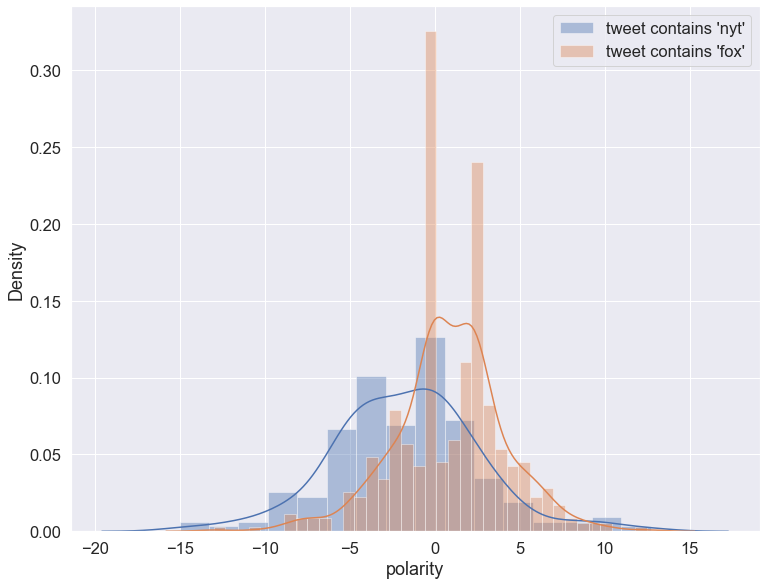

In [303]:
### BEGIN SOLUTION
plt.figure(figsize=(11, 9))
nyt = df_trump[df_trump['text'].str.contains('nyt', case=False)]
fox = df_trump[df_trump['text'].str.contains('fox', case=False)]
sns.distplot(nyt['polarity'], label = "tweet contains 'nyt'")
sns.distplot(fox['polarity'], label = "tweet contains 'fox'")
plt.legend()
plt.show()
### END SOLUTION

##### Comment on what you observe:

#### BEGIN SOLUTION


#### END SOLUTION

## PART 5 - Principal Component Analysis (PCA) and Twitter
A look at the top words used and the sentiments expressed in Trump tweets indicates that, some words are used with others almost all the time. A notable example is the slogan like Make America Great Again. As such, it may be beneficial to look at groups of words rather than individual words. For that, we will look at an approach applying a Principal Component Analysis. 

### The PCA
The Principal Component Analysis, or PCA, is a tool generally used to identify patterns and to reduce the number of variables you have to consider in your analysis. For example, if you have data with 200 columns, it may be that a significant amount of the variance in your data can be explained by just 100 principal components. In the PCA, the first component is chosen in such a way that has the largest variance, subsequent components are orthogonal and continue covering as much variance as possible. In this way, the PCA samples as much of the variability in the data set with the first few components. Mathematically, each component is a linear combination of all the input parameters times coefficients specific for that component. These coefficients, or loading factors, are constrained such that the sum of the squares of them are equal to 1. As such, the loading factors serve as weights describing how strongly certain parameters contribute to the specific principal component. Parameters with large values of positive or negative loading factors are correlated with each other, which can serve to identify trends in your data.

### Task 5.1 Cleaning up the Data
Using NLTK (Natural Language Toolkit) package for language processing and other python libraries, parse the json file to deal with inflected words, such as plurals, and removed stop words like common English words (the, and, it, etc) and certain political terms (the candidates names, for example). You can start with the top 50 words, but full analysis may require large number of words.
Create a document-frequecy (df) matrix with 5000 rows and 50 columns where each column is a particular word (feature) and each row is a tweet (observation). The values of the matrix is how often the word appears. Apply the techniques we learned to reduce the weight of most common words (if necessary). Since this is a sparse matrix, you can use the sparse martix libraries to make things a bit more efficient (we can also use a regular numpy arrays to store these things since the dimensions are not too large). Lecture 6.1 captures some sparse matrix routines you can use.
Print the first 10 rows of the df to show the matrix you created

Start with the `tidy_format` dataframe

In [325]:
### BEGIN SOLUTION
## code to plot the first 10 rows of the matrix
import nltk
import nltk.corpus
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer


#create a dataframe called tmp to store all words appear in the tweets
tmp = pd.DataFrame(tidy_format['word'])
tmp = tmp.reset_index(drop = True)
#display(tmp)
#remove stopwords

stop = stopwords.words('english')
#print(stop)
tmp['word_wo_stopwords'] = tmp['word'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop)]))
tmp= tmp.drop(['word'], axis = 1)
tmp = tmp.replace(r'\s+',np.nan,regex=True).replace('',np.nan)
#tmp
tmp = tmp.dropna()
tmp = tmp.reset_index(drop=True)
tmp.columns=['word']
#display(tmp)

#deal with plurals
wnl = WordNetLemmatizer()

#tmp['text_lemmatized'] = tmp.text.apply(lemmatize_text)display(tmp)
tmp['word_wo_plural']=tmp['word'].apply(lambda row:''.join([wnl.lemmatize(w) for w in row]))
tmp= tmp.drop(['word'], axis = 1)
tmp.columns=['word']
#display(tmp.head(20))
# Remove numberstmp
tmp['word'] = tmp['word'].str.replace('\d+', '')
#display(tmp.head(20))          

#Remove words with only 1 or 2 length
tmp['word']=tmp['word'].str.split().map(lambda x: " ".join(word for word in x if len(word) > 3))
tmp = tmp.replace(r'\s+',np.nan,regex=True).replace('',np.nan)
tmp = tmp.dropna()
tmp = tmp.reset_index(drop=True)
#display(tmp['word'].head(20))


doc_freq = pd.DataFrame(columns = tmp['word'].head(50), index = df_trump['no_punc'].head(5000))
ii = 0
for idx, row in doc_freq.iterrows():
    for index, x in row.iteritems():
        nstr = idx
        ddd = nstr.count(index)
        row[index] = ddd
    ii = ii+1
    if ii == 10:
        break
display(doc_freq.head(10))

### END SOLUTION




[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ranju\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ranju\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
C:\Users\ranju\AppData\Local\Temp/ipykernel_23304/196942229.py:36: FutureWarning: The default value of regex will change from True to False in a future version.
  tmp['word'] = tmp['word'].str.replace('\d+', '')


word,register,https,pwiwchgbh,maga,https,actmetzu,whitehouse,https,rnqlpotso,really,...,contact,justice,department,official,bruce,used,simpson,steele,back,channel
no_punc,,,,,,,,,,,,,,,,,,,,,
register to https t co 0pwiwchgbh maga https t co actme53tzu,1,2,1,1,2,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
rt whitehouse https t co rnqlpots3o,0,1,0,0,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
is it really possible that bruce ohr whose wife nellie was paid by simpson and gps fusion for work done on the fake dossier and who was used as a pawn in this whole scam witch hunt is still working for the department of justice can this really be so,0,0,0,0,0,0,0,0,0,2,...,0,1,1,0,1,1,1,0,0,0
conflict between glen simpson s testimony to another house panel about his contact with justice department official bruce ohr ohr was used by simpson and steele as a back channel to get fake dossier to fbi simpson pleading fifth catherine herridge where is jeff sessions,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,3,1,1,1
federal judge throws out stormy danials lawsuit versus trump trump is entitled to full legal fees foxnews great now i can go after horseface and her 3rd rate lawyer in the great state of texas she will confirm the letter she signed she knows nothing about me a total con,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
incredible number just out 7 036 000 job openings astonishing it s all working stock market up big on tremendous potential of usa also strong profits we are number one in world by far,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
for the record i have no financial interests in saudi arabia or russia for that matter any suggestion that i have is just more fake news of which there is plenty,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8x more new manufacturing jobs now than with obama foxnews cvpayne,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
the united states has strongly informed the president of honduras that if the large caravan of people heading to the u s is not stopped and brought back to honduras no more money or aid will be given to honduras effective immediately,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


### Task 5.2 Find the PCA's
Write the code to find the first 50 PCA's for the document-frequency matrix. Pass the document-term-matrix to scikit-learn’s (https://scikit-learn.org/stable/modules/decomposition.html#decompositions) PCA method to obtain the components and loading factors.

In [345]:
### BEGIN SOLUTION
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
ii = 0
for idx, row in doc_freq.iterrows():
    for index, x in row.iteritems():
        nstr = idx
        ddd = nstr.count(index)
        row[index] = ddd
    ii = ii+1
    if ii == 50:
        break
        
lol = doc_freq.head(50)
display(lol)
scaler = MinMaxScaler()
data_rescaled = scaler.fit_transform(lol)

pca = PCA(n_components = 0.95)
pca.fit(data_rescaled)
reduced = pca.transform(data_rescaled)

### END SOLUTION

word,register,https,pwiwchgbh,maga,https,actmetzu,whitehouse,https,rnqlpotso,really,...,contact,justice,department,official,bruce,used,simpson,steele,back,channel
no_punc,,,,,,,,,,,,,,,,,,,,,
register to https t co 0pwiwchgbh maga https t co actme53tzu,1,2,1,1,2,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
rt whitehouse https t co rnqlpots3o,0,1,0,0,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
is it really possible that bruce ohr whose wife nellie was paid by simpson and gps fusion for work done on the fake dossier and who was used as a pawn in this whole scam witch hunt is still working for the department of justice can this really be so,0,0,0,0,0,0,0,0,0,2,...,0,1,1,0,1,1,1,0,0,0
conflict between glen simpson s testimony to another house panel about his contact with justice department official bruce ohr ohr was used by simpson and steele as a back channel to get fake dossier to fbi simpson pleading fifth catherine herridge where is jeff sessions,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,3,1,1,1
federal judge throws out stormy danials lawsuit versus trump trump is entitled to full legal fees foxnews great now i can go after horseface and her 3rd rate lawyer in the great state of texas she will confirm the letter she signed she knows nothing about me a total con,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
incredible number just out 7 036 000 job openings astonishing it s all working stock market up big on tremendous potential of usa also strong profits we are number one in world by far,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
for the record i have no financial interests in saudi arabia or russia for that matter any suggestion that i have is just more fake news of which there is plenty,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8x more new manufacturing jobs now than with obama foxnews cvpayne,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
the united states has strongly informed the president of honduras that if the large caravan of people heading to the u s is not stopped and brought back to honduras no more money or aid will be given to honduras effective immediately,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


### Task 5.3 Examine the PCA
We can examine the PCA results to look at the heatmap. Make a grid plot which shows the various principal component along the x-axis and the individual words along the y-axes. Each grid box should be color-coded based on the sign of the loading factor and how large the square of that value is. Looking at it vertically, you can see which words constitute your principal components. Looking at it horizontally, you can see how individual terms are shared between components. 

![title](images/pca.png)



In [363]:
### BEGIN SOLUTION
#print(reduced)
sns.set(font_scale=5)
ax = sns.heatmap(reduced,
                 cmap='YlGnBu',
                 xticklabels=['PC'+str(x) for x in range(1,pca.n_components_+1)],
                     yticklabels=list(lol.columns),
                 cbar_kws={"orientation": "horizontal"})
ax.set_aspect("equal")
sns.set(rc = {'figure.figsize':(50,50)})
### END SOLUTION

ValueError: Image size of 82800x7200 pixels is too large. It must be less than 2^16 in each direction.

ValueError: Image size of 82800x7200 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 82800x7200 with 2 Axes>

### Task 5.4 PCA Compare
We can determine how many words and how many components are needed to do a good visualization. Plot PC1 and PC2 in a 2D plot. The results should be similar to following scatter plot 

![title](images/PC1_PC2.png)

This is a scatter plot of the values of the components, but with arrows indicating some of the prominent terms as indicated by their loading factors. The values of the loading factors are used to determine the length and direction of these arrows and as such they serve as a way of expressing direction. That is, tweets which use these terms will be moved along the length of those arrows. Shown are the most important parameters.

In [ ]:
### BEGIN SOLUTION


### END SOLUTION

## PART 6 - Twitter Engagement

In this problem, we'll explore which words led to a greater average number of retweets. For example, at the time of this writing, Donald Trump has two tweets that contain the word 'oakland' (tweets 932570628451954688 and 1016609920031117312) with 36757 and 10286 retweets respectively, for an average of 23,521.5.


Your `top_20` table should have this format:

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>retweet_count</th>
    </tr>
    <tr>
      <th>word</th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>jong</th>
      <td>40675.666667</td>
    </tr>
    <tr>
      <th>try</th>
      <td>33937.800000</td>
    </tr>
    <tr>
      <th>kim</th>
      <td>32849.595745</td>
    </tr>
    <tr>
      <th>un</th>
      <td>32741.731707</td>
    </tr>
    <tr>
      <th>maybe</th>
      <td>30473.192308</td>
    </tr>
  </tbody>
</table>

### Task 6.1
Find the top 20 most retweeted words. Include only words that appear in at least 25 tweets. As usual, try to do this without any for loops. You can string together ~5-7 pandas commands and get everything done on one line.

In [272]:
#top_20 = (tidy_format.groupby('word').filter(lambda x: len(x) >= 25)
             # .merge(df_trump, how='inner', right_index=True, left_index=True)
              #.groupby('word').agg({'retweet_count': 'mean'}).sort_values(by='retweet_count', ascending=False))
### BEGIN SOLUTION
top_20 = (tidy_format.groupby('word').filter(lambda x: len(x) >= 25)
              .merge(df_trump, how='inner', right_index=True, left_index=True)
              .groupby('word').agg({'retweet_count': 'mean'}).sort_values(by='retweet_count', ascending=False))
top_20 = top_20.iloc[0:20, :]
display(top_20)
### END SOLUTION

,retweet_count
word,
jong,47298.709677
maybe,38895.259259
kim,36585.120000
un,36560.477273
try,36476.156250
old,35712.257143
christmas,33285.629630
short,32944.321429
kavanaugh,28651.962963


### Task 6.2
Plot a bar chart of your results:

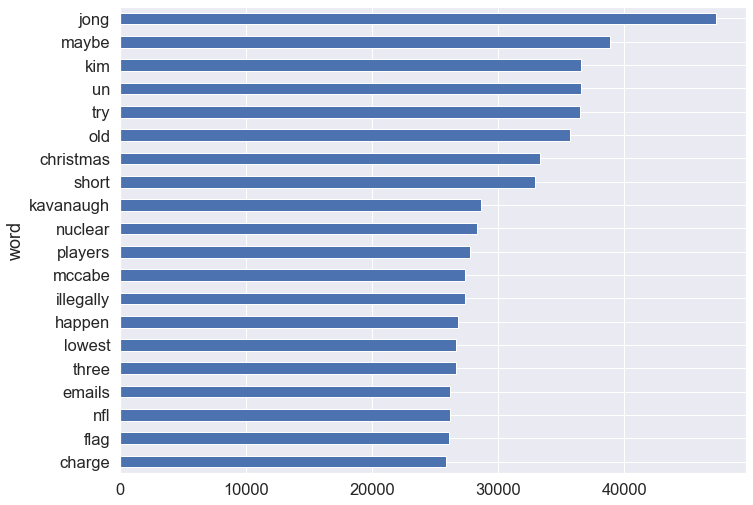

In [273]:
### BEGIN SOLUTION

top_20['retweet_count'].sort_values().plot.barh(figsize=(10, 8));
### BEGIN SOLUTION